# Homework 3 — Evaluation (10 Points)

Quantify the trained pix2pixHD using **SSIM** between the generated brightfield and the
ground-truth brightfield. We compare four milestone checkpoints (5, 10, 20, 40) and probe
the model with random binary masks it never saw during training.

In [1]:
import os, glob, subprocess, sys, random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw
from skimage.metrics import structural_similarity as ssim
print("Libraries ready.")

Libraries ready.


## 1. Run inference on the test set

`test.py` writes results to `pix2pixHD/results/<name>/test_<epoch>/images/`. We
use `sys.executable` so the subprocess uses the same Python (and dependencies) as the
notebook kernel.

In [29]:
checkpoints_dir = "pix2pixHD/checkpoints"
results_dir     = "pix2pixHD/results"
dataroot        = "datasets/bbbc010_pix2pixhd"
name            = "bbbc010_512"
# TODONE: list the milestone epochs you saved during training
epochs          = [5, 10, 20, 40]
N_TEST          = 20

for ep in epochs:
    out_folder = f"{results_dir}/{name}/test_{ep}"
    if os.path.exists(out_folder) and len(glob.glob(f"{out_folder}/images/*.jpg")) > 0:
        print(f"Epoch {ep} already inferred.")
        continue
    cmd = [
        sys.executable, "pix2pixHD/test.py",
        "--name", name,
        "--dataroot", dataroot,
        "--label_nc", "0",
        "--no_instance",
        "--loadSize", "512",
        "--fineSize", "512",
        "--which_epoch", str(ep),
        "--how_many", str(N_TEST),
        "--checkpoints_dir", checkpoints_dir,
        "--results_dir", results_dir,
    ]
    print(f"Running inference for epoch {ep} ...")
    r = subprocess.run(cmd, capture_output=True, text=True)
    if r.returncode != 0:
        print(r.stdout[-2000:]); print(r.stderr[-2000:])
        raise RuntimeError(f"test.py failed at epoch {ep}")
print("All epochs ready.")

Epoch 5 already inferred.
Epoch 10 already inferred.
Epoch 20 already inferred.
Epoch 40 already inferred.
All epochs ready.


In [43]:
for ep in epochs:
    cmd = [
        sys.executable, "pix2pixHD/test.py",
        "--name", name,
        "--dataroot", "datasets/random",
        "--label_nc", "0",
        "--no_instance",
        "--loadSize", "512",
        "--fineSize", "512",
        "--which_epoch", str(ep),
        "--how_many", str(N_TEST),
        "--checkpoints_dir", checkpoints_dir,
        "--results_dir", "pix2pixHD/random_results",
    ]
    print(f"Running inference for epoch {ep} ...")
    r = subprocess.run(cmd, capture_output=True, text=True)
    if r.returncode != 0:
        print(r.stdout[-2000:]); print(r.stderr[-2000:])
        raise RuntimeError(f"test.py failed at epoch {ep}")
print("All epochs ready.")

Running inference for epoch 5 ...
Running inference for epoch 10 ...
Running inference for epoch 20 ...
Running inference for epoch 40 ...
All epochs ready.


## 2. SSIM per epoch

For each milestone, compute SSIM between every generated image and its real ground-truth.

In [35]:
real_dir = "datasets/bbbc010_pix2pixhd/test_B"

def ssim_for_epoch(ep):
    res_dir = f"{results_dir}/{name}/test_{ep}/images"
    files = sorted(glob.glob(f"{res_dir}/*_synthesized_image.jpg"))
    vals = []
    for synth in files:
        base = os.path.basename(synth).replace("_synthesized_image.jpg", "")
        real = os.path.join(real_dir, base + ".png")
        if not os.path.exists(real): continue
        g = np.array(Image.open(synth)).astype(np.float32)
        r = np.array(Image.open(real)).astype(np.float32)
        # print(g.shape)
        # TODONE: compute SSIM on the luminance (grayscale) channel
        # Hint: average the RGB channels to get luminance; data_range is 255 for uint8 images
        vals.append(ssim(g.mean(axis=2), r.mean(axis=2), data_range=255))
    return np.array(vals)

per_ep = {ep: ssim_for_epoch(ep) for ep in epochs}
print(f"{'epoch':>6} | {'mean':>6} | {'std':>6} | {'min':>6} | {'max':>6}")
print("-" * 42)
for ep in epochs:
    v = per_ep[ep]
    print(f"{ep:>6} | {v.mean():>6.3f} | {v.std():>6.3f} | {v.min():>6.3f} | {v.max():>6.3f}")

 epoch |   mean |    std |    min |    max
------------------------------------------
     5 |  0.547 |  0.022 |  0.498 |  0.589
    10 |  0.574 |  0.020 |  0.532 |  0.605
    20 |  0.763 |  0.019 |  0.711 |  0.789
    40 |  0.825 |  0.021 |  0.767 |  0.855


### SSIM trend

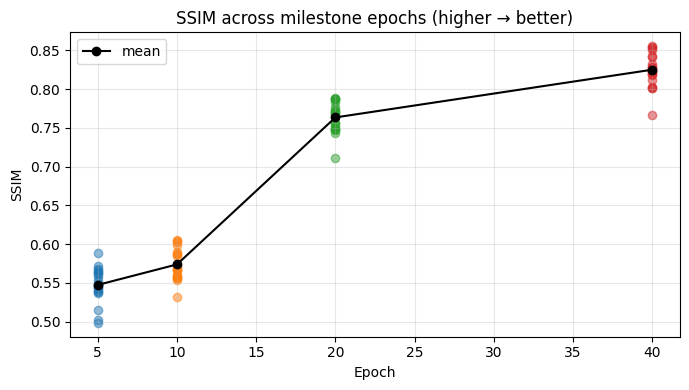

In [36]:
fig, ax = plt.subplots(1, 1, figsize=(7, 4))
for ep in epochs:
    ax.scatter([ep]*len(per_ep[ep]), per_ep[ep], alpha=0.5)
ax.plot(epochs, [per_ep[ep].mean() for ep in epochs], "k-o", label="mean")
ax.set_xlabel("Epoch"); ax.set_ylabel("SSIM"); ax.set_title("SSIM across milestone epochs (higher → better)")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 3. Side-by-side comparison

Pick the first test sample and show how its generation evolves across milestones.
Optionally try a second sample.

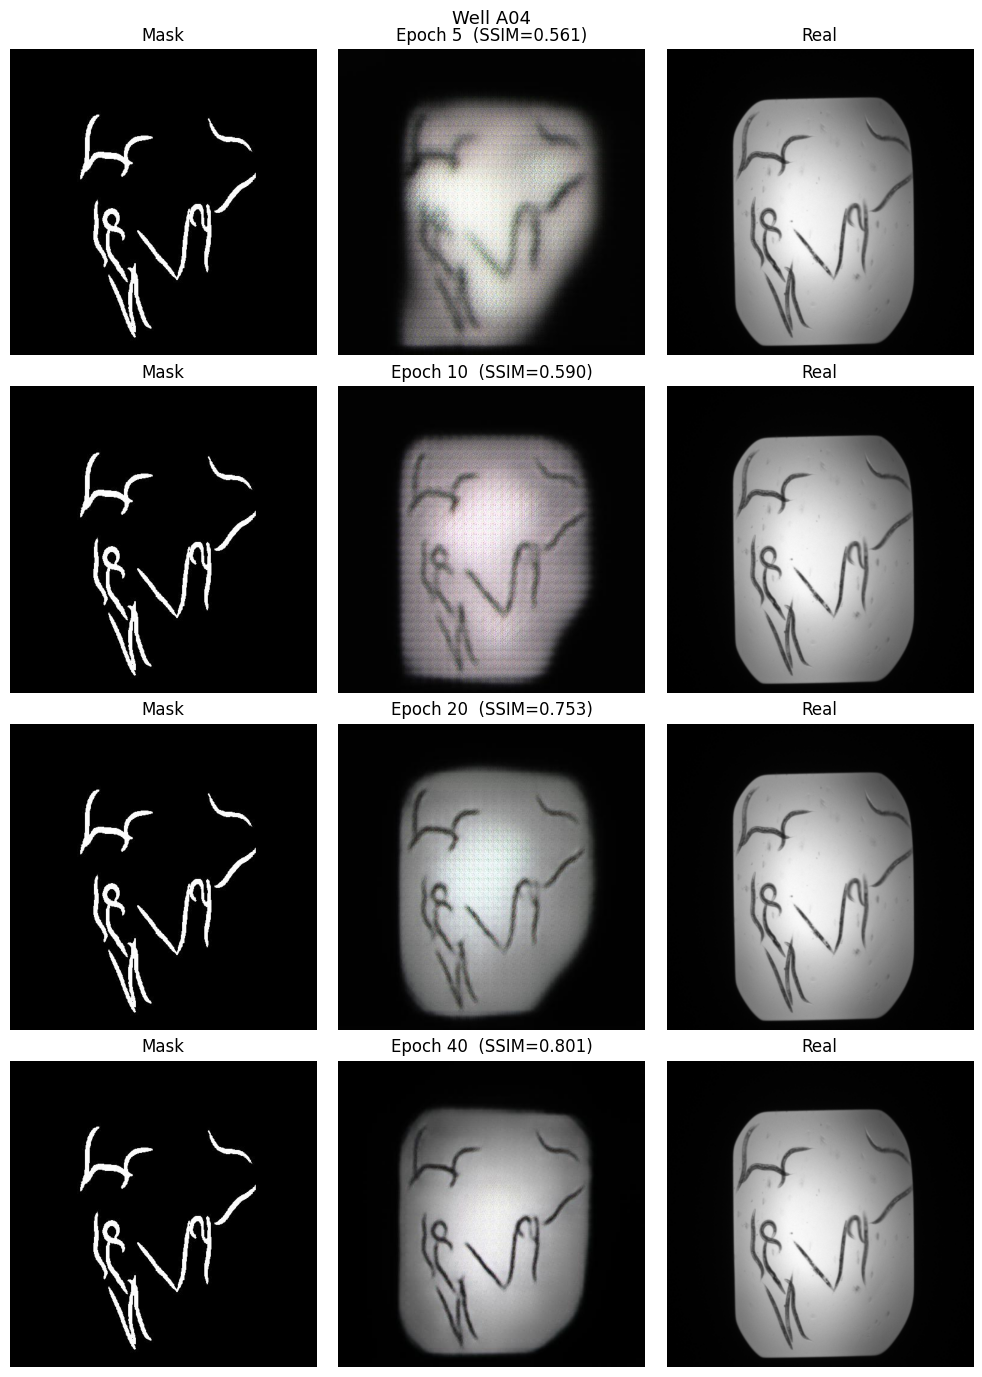

In [37]:
sample_base = None
for ep in epochs:
    f = sorted(glob.glob(f"{results_dir}/{name}/test_{ep}/images/*_synthesized_image.jpg"))
    if f: sample_base = os.path.basename(f[0]).replace("_synthesized_image.jpg", ""); break

if sample_base is None:
    print("No results found.")
else:
    fig, axes = plt.subplots(len(epochs), 3, figsize=(10, 3.5*len(epochs)))
    for row, ep in enumerate(epochs):
        rd = f"{results_dir}/{name}/test_{ep}/images"
        mask_p = f"{rd}/{sample_base}_input_label.jpg"
        gen_p  = f"{rd}/{sample_base}_synthesized_image.jpg"
        real_p = f"{real_dir}/{sample_base}.png"
        if not (os.path.exists(gen_p) and os.path.exists(real_p)):
            continue
        mask = np.array(Image.open(mask_p))
        gen  = np.array(Image.open(gen_p))
        real = np.array(Image.open(real_p))
        # TODONE: same SSIM as above — generated vs real, luminance, data_range=255
        s = ssim(gen.mean(axis=2), real.mean(axis=2), data_range=255)
        axes[row, 0].imshow(mask); axes[row, 0].set_title("Mask")
        axes[row, 1].imshow(gen);  axes[row, 1].set_title(f"Epoch {ep}  (SSIM={s:.3f})")
        axes[row, 2].imshow(real); axes[row, 2].set_title("Real")
        for a in axes[row]: a.axis("off")
    plt.suptitle(f"Well {sample_base}", fontsize=13)
    plt.tight_layout(); plt.show()

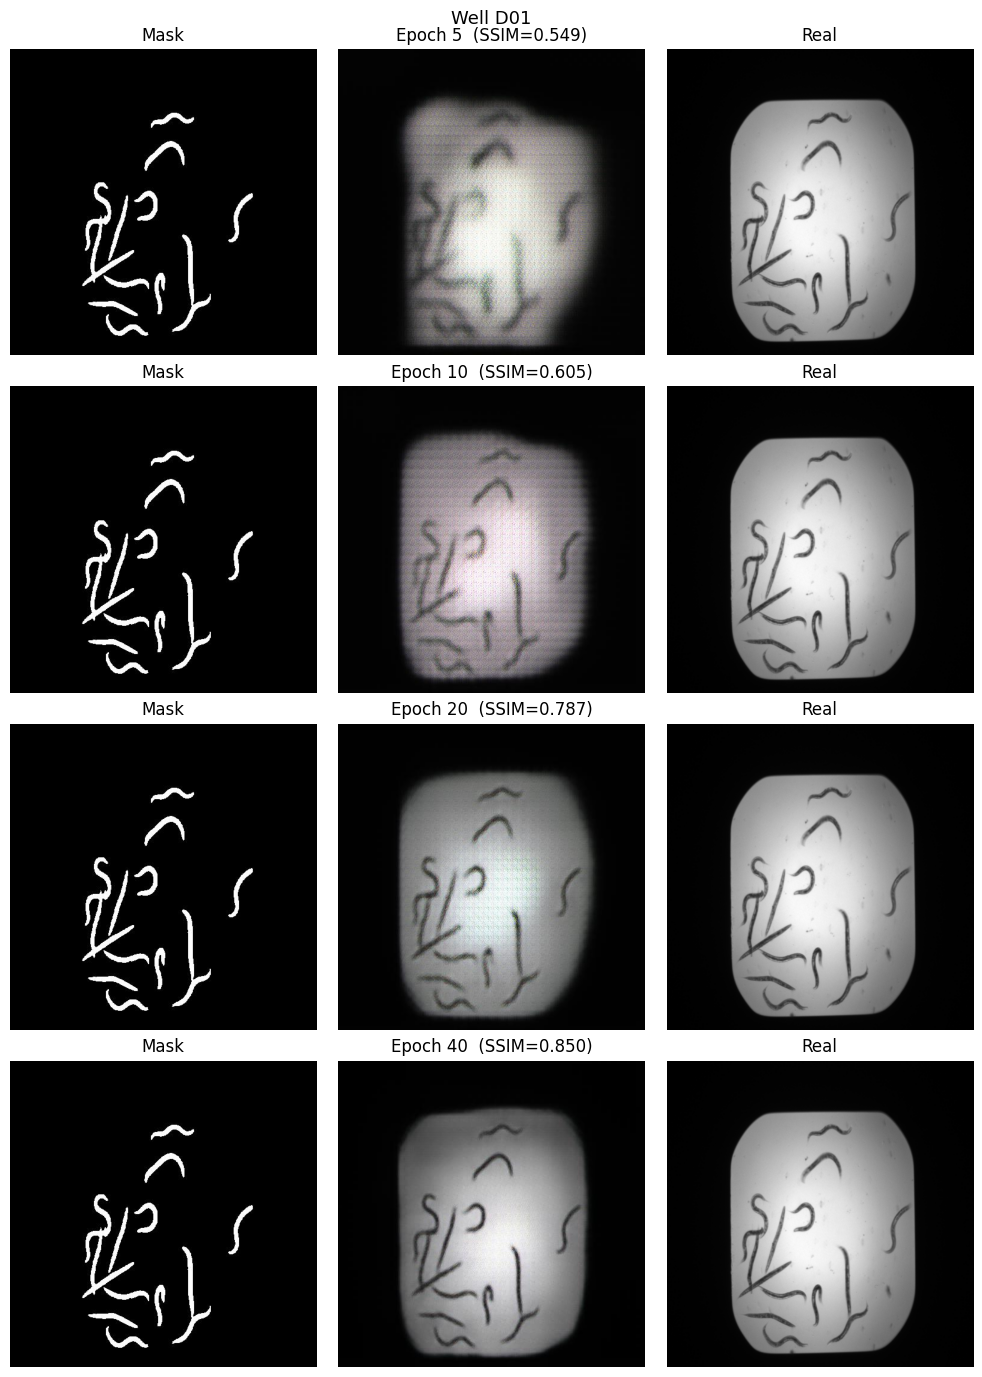

In [38]:
sample_base = None
for ep in epochs:
    f = sorted(glob.glob(f"{results_dir}/{name}/test_{ep}/images/*_synthesized_image.jpg"))
    if f: sample_base = os.path.basename(f[-5]).replace("_synthesized_image.jpg", ""); break

if sample_base is None:
    print("No results found.")
else:
    fig, axes = plt.subplots(len(epochs), 3, figsize=(10, 3.5*len(epochs)))
    for row, ep in enumerate(epochs):
        rd = f"{results_dir}/{name}/test_{ep}/images"
        mask_p = f"{rd}/{sample_base}_input_label.jpg"
        gen_p  = f"{rd}/{sample_base}_synthesized_image.jpg"
        real_p = f"{real_dir}/{sample_base}.png"
        if not (os.path.exists(gen_p) and os.path.exists(real_p)):
            continue
        mask = np.array(Image.open(mask_p))
        gen  = np.array(Image.open(gen_p))
        real = np.array(Image.open(real_p))
        # TODONE: same SSIM as above — generated vs real, luminance, data_range=255
        s = ssim(gen.mean(axis=2), real.mean(axis=2), data_range=255)
        axes[row, 0].imshow(mask); axes[row, 0].set_title("Mask")
        axes[row, 1].imshow(gen);  axes[row, 1].set_title(f"Epoch {ep}  (SSIM={s:.3f})")
        axes[row, 2].imshow(real); axes[row, 2].set_title("Real")
        for a in axes[row]: a.axis("off")
    plt.suptitle(f"Well {sample_base}", fontsize=13)
    plt.tight_layout(); plt.show()

In [41]:
f

['pix2pixHD/results/bbbc010_512/test_5/images/A04_synthesized_image.jpg',
 'pix2pixHD/results/bbbc010_512/test_5/images/A10_synthesized_image.jpg',
 'pix2pixHD/results/bbbc010_512/test_5/images/A11_synthesized_image.jpg',
 'pix2pixHD/results/bbbc010_512/test_5/images/A12_synthesized_image.jpg',
 'pix2pixHD/results/bbbc010_512/test_5/images/A17_synthesized_image.jpg',
 'pix2pixHD/results/bbbc010_512/test_5/images/A21_synthesized_image.jpg',
 'pix2pixHD/results/bbbc010_512/test_5/images/B03_synthesized_image.jpg',
 'pix2pixHD/results/bbbc010_512/test_5/images/B06_synthesized_image.jpg',
 'pix2pixHD/results/bbbc010_512/test_5/images/B08_synthesized_image.jpg',
 'pix2pixHD/results/bbbc010_512/test_5/images/B10_synthesized_image.jpg',
 'pix2pixHD/results/bbbc010_512/test_5/images/B21_synthesized_image.jpg',
 'pix2pixHD/results/bbbc010_512/test_5/images/B24_synthesized_image.jpg',
 'pix2pixHD/results/bbbc010_512/test_5/images/C07_synthesized_image.jpg',
 'pix2pixHD/results/bbbc010_512/test_5

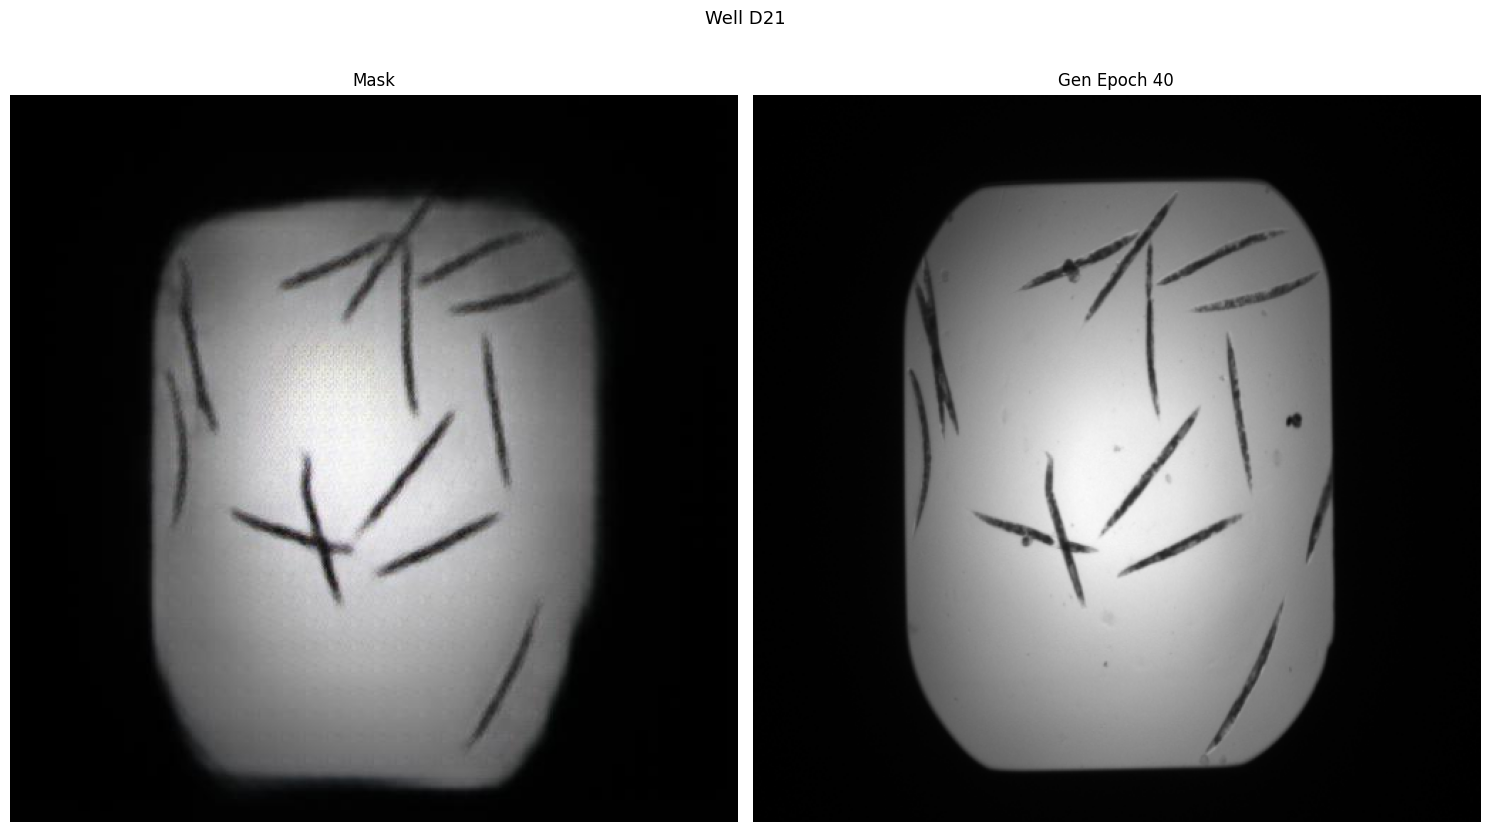

In [ ]:
sample_base = None
for ep in epochs:
    f = sorted(glob.glob(f"{results_dir}/{name}/test_{ep}/images/*_synthesized_image.jpg"))
    if f: sample_base = os.path.basename(f[-1]).replace("_synthesized_image.jpg", ""); break

if sample_base is None:
    print("No results found.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(15, 9))
    for row, ep in enumerate(epochs[-1:]):
        rd = f"{results_dir}/{name}/test_{ep}/images"
        mask_p = f"{rd}/{sample_base}_input_label.jpg"
        gen_p  = f"{rd}/{sample_base}_synthesized_image.jpg"
        real_p = f"{real_dir}/{sample_base}.png"
        if not (os.path.exists(gen_p) and os.path.exists(real_p)):
            continue
        mask = np.array(Image.open(mask_p))
        gen  = np.array(Image.open(gen_p))
        real = np.array(Image.open(real_p))
        # TODONE: same SSIM as above — generated vs real, luminance, data_range=255
        s = ssim(gen.mean(axis=2), real.mean(axis=2), data_range=255)
        axes[0].imshow(gen);  axes[0].set_title(f"Mask")
        axes[1].imshow(real); axes[1].set_title("Gen Epoch 40")
        for a in axes: a.axis("off")
    plt.suptitle(f"Well {sample_base}", fontsize=13)
    plt.tight_layout(); plt.show()

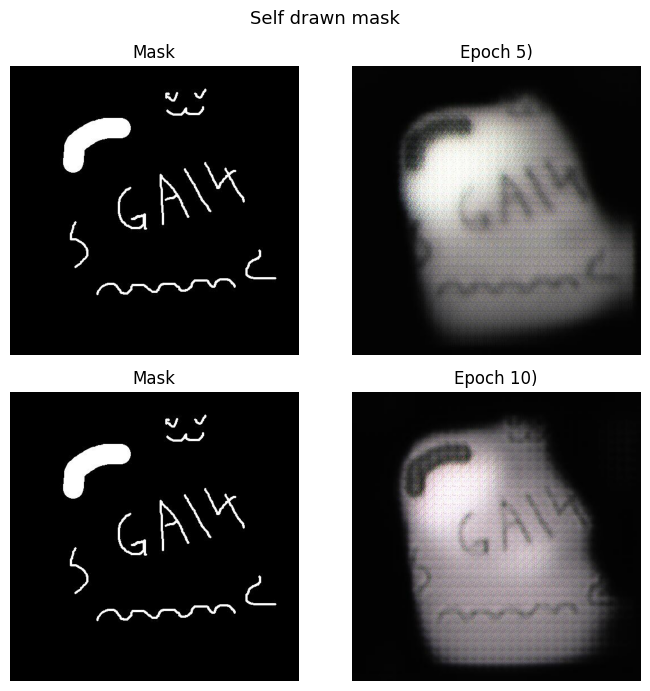

In [63]:
sample_base = None
for ep in epochs:
    f = sorted(glob.glob(f"pix2pixHD/random_results/{name}/test_{ep}/images/*_synthesized_image.jpg"))
    if f: sample_base = os.path.basename(f[0]).replace("_synthesized_image.jpg", ""); break

if sample_base is None:
    print("No results found.")
else:
    fig, axes = plt.subplots(2, 2, figsize=(7, 3.5*2))
    for row, ep in enumerate(epochs[:2]):
        rd = f"pix2pixHD/random_results/{name}/test_{ep}/images"
        mask_p = f"{rd}/{sample_base}_input_label.jpg"
        gen_p  = f"{rd}/{sample_base}_synthesized_image.jpg"
        if not os.path.exists(gen_p) :
            continue
        mask = np.array(Image.open(mask_p))
        gen  = np.array(Image.open(gen_p))
        # TODONE: same SSIM as above — generated vs real, luminance, data_range=255
        axes[row, 0].imshow(mask); axes[row, 0].set_title("Mask")
        axes[row, 1].imshow(gen);  axes[row, 1].set_title(f"Epoch {ep})")
        for a in axes[row]: a.axis("off")
    plt.suptitle(f"Self drawn mask", fontsize=13)
    plt.tight_layout(); plt.show()

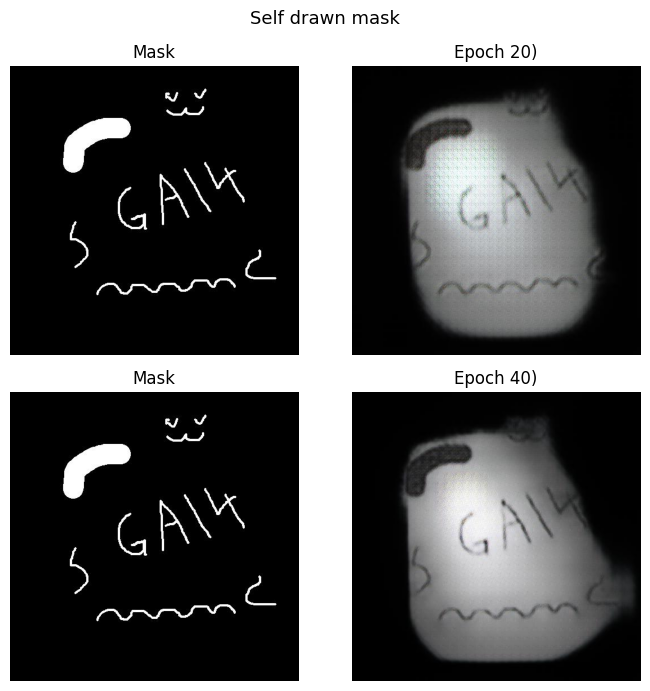

In [64]:
fig, axes = plt.subplots(2, 2, figsize=(7, 3.5*2))
for row, ep in enumerate(epochs[2:]):
    rd = f"pix2pixHD/random_results/{name}/test_{ep}/images"
    mask_p = f"{rd}/{sample_base}_input_label.jpg"
    gen_p  = f"{rd}/{sample_base}_synthesized_image.jpg"
    if not os.path.exists(gen_p) :
        continue
    mask = np.array(Image.open(mask_p))
    gen  = np.array(Image.open(gen_p))
    # TODONE: same SSIM as above — generated vs real, luminance, data_range=255
    axes[row, 0].imshow(mask); axes[row, 0].set_title("Mask")
    axes[row, 1].imshow(gen);  axes[row, 1].set_title(f"Epoch {ep})")
    for a in axes[row]: a.axis("off")
plt.suptitle(f"Self drawn mask", fontsize=13)
plt.tight_layout(); plt.show()

## 4. Discussion

* **Does SSIM plateau?**
* **Do you see any artifacts in generated samples?**

## Conclusion

**Does SSIM plateau**

Eventually yes (a very nice s curve is currently visible in the training steps). But within our 40 epochs it has not yet plateaued and would most likly not for a quite a few more epochs as the model irons out some of its bumps. (It has "only" achieved 80% accuracy yet)

**Do you see any artifacts in generated samples**

For fairness to the GAN here I used only the last epoch (40). In the above image (enlarged to better see the images), yes you can see that the GANs generation is far from perfect.

* The worms are all mono colour and have none of the transperancy and colour gradient of the original
* The sides of the "dish/image?" - the white thing of the worms - has some artifacting with non-smooth edes and light colour creeping, making it seem more blurry
* the image is more blurry overall
* The colour of the background is slightly off